## Test 1

Using file: TEST1_ems_demo_20260512_122830
Rows: 96
Columns: 46
Saved PNG: analysis_results\TEST1_ems_demo_20260512_122830_timeline.png
Saved PDF: analysis_results\TEST1_ems_demo_20260512_122830_timeline.pdf


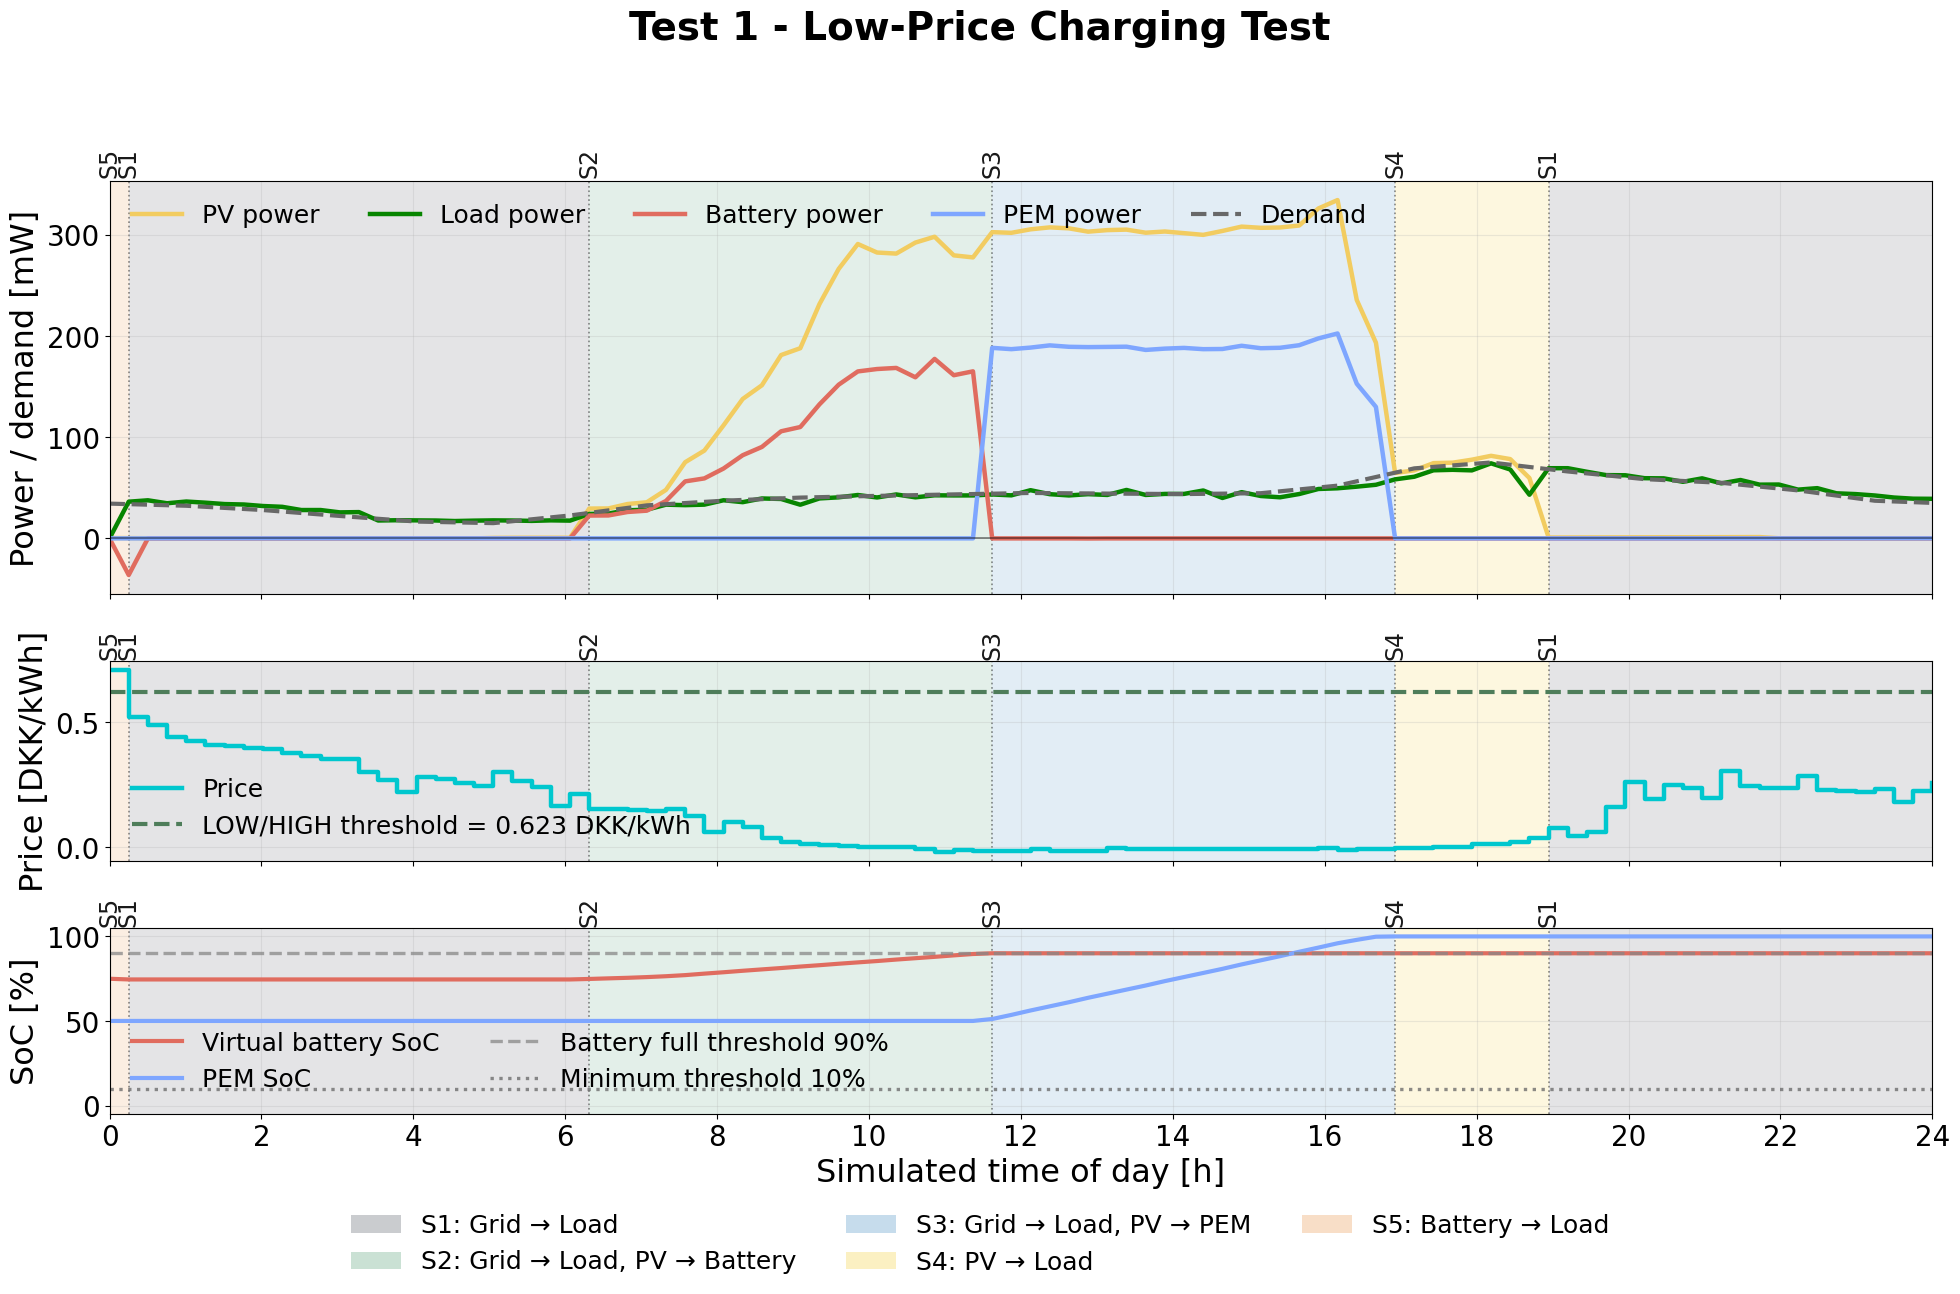

,Simulated time,Timeslot,Scenario,EMS reason
0,00:00,00:00-00:15,S5,"HIGH price, PV unavailable and battery has ene..."
1,00:15,00:15-00:30,S1,LOW price and PV unavailable -> grid supplies ...
25,06:15,06:15-06:30,S2,"LOW price, PV available and battery below 90% ..."
46,11:30,11:30-11:45,S3,"LOW price, PV available, battery above 90% and..."
67,16:45,16:45-17:00,S4,"LOW price, PV available, battery above 90% and..."
75,18:45,18:45-19:00,S1,LOW price and PV unavailable -> grid supplies ...


Saved transition table: analysis_results\TEST1_ems_demo_20260512_122830_scenario_transitions.csv


In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# File path
# ============================================================

# The IPYNB file is assumed to be in the same folder as the CSV file.
csv_path = Path(r"TEST1_ems_demo_20260512_122830")

# If the filepath was given without .csv, try adding it.
if not csv_path.exists() and csv_path.suffix == "":
    csv_path = csv_path.with_suffix(".csv")

print("Using file:", csv_path)


# ============================================================
# User settings
# ============================================================

scenario_column = "target_scenario"   # use "actual_scenario" to plot applied system scenario instead
show_soc = True
save_plot = True

plot_title = "Test 1 - Low-Price Charging Test"

price_threshold = 0.623   # DKK/kWh, LOW/HIGH threshold

out_dir = Path("analysis_results")
out_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# Report-friendly text sizes
# ============================================================

TITLE_SIZE = 28
AXIS_LABEL_SIZE = 23
TICK_LABEL_SIZE = 20
LEGEND_SIZE = 18
ANNOTATION_SIZE = 17

plt.rcParams.update({
    "font.size": TICK_LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})


# ============================================================
# Colors
# ============================================================

WEBUI_COLORS = {
    "price": "#00C7CE",
    "price_threshold": "#4E7D5A",
    "demand": "#686868",
    "pv_power": "#F2CC60",
    "load_power": "#078500",
    "battery_power": "#E06C5F",
    "pem_power": "#7EA6FF",
}

SCENARIO_COLORS = {
    "S1": "#2f3542",
    "S2": "#2e8b57",
    "S3": "#1f77b4",
    "S4": "#f1c40f",
    "S5": "#e67e22",
    "S6": "#8e44ad",
}

SCENARIO_LABELS = {
    "S1": "S1: Grid → Load",
    "S2": "S2: Grid → Load, PV → Battery",
    "S3": "S3: Grid → Load, PV → PEM",
    "S4": "S4: PV → Load",
    "S5": "S5: Battery → Load",
    "S6": "S6: PEM → Load",
}


# ============================================================ 
# Helper functions
# ============================================================

def parse_time_axis_0_to_24(df):
    """
    Creates a simulated time-of-day x-axis from 0 to 24 hours.
    Uses time_label if available, otherwise slot, otherwise sample index.
    """

    if "time_label" in df.columns:
        parsed = pd.to_timedelta(df["time_label"].astype(str), errors="coerce")

        if parsed.notna().sum() > 0.5 * len(df):
            x = parsed.dt.total_seconds() / 3600.0
            return x, "Simulated time of day [h]"

    if "slot" in df.columns:
        slot = pd.to_numeric(df["slot"], errors="coerce")

        if slot.notna().sum() > 0.5 * len(df):
            slot_min = slot.min()
            slot_max = slot.max()

            if slot_max > slot_min:
                x = 24.0 * (slot - slot_min) / (slot_max - slot_min)
            else:
                x = slot * 0.0

            return x, "Simulated time of day [h]"

    sample_index = pd.Series(np.arange(len(df)), index=df.index)

    if len(df) > 1:
        x = 24.0 * sample_index / (len(df) - 1)
    else:
        x = sample_index * 0.0

    return x, "Simulated time of day [h]"


def normalize_scenario(value):
    """
    Converts scenario values such as S1, S1 Grid -> Load, or 1 into S1.
    """

    if pd.isna(value):
        return "Unknown"

    text = str(value).strip().upper()

    for scenario in ["S1", "S2", "S3", "S4", "S5", "S6"]:
        if text.startswith(scenario):
            return scenario

    if text in ["1", "2", "3", "4", "5", "6"]:
        return f"S{text}"

    return text


def find_transition_mask(scenario):
    """
    Returns True where the scenario changes.
    The first row is also treated as a transition/start point.
    """

    scenario_reset = scenario.reset_index(drop=True)
    return scenario_reset.ne(scenario_reset.shift())


def get_scenario_segments(x, scenario):
    """
    Converts the scenario series into continuous background regions.
    """

    x_values = x.to_numpy(dtype=float)
    scen_values = scenario.to_numpy()

    if len(x_values) == 0:
        return []

    dx_values = np.diff(x_values)
    dx_values = dx_values[np.isfinite(dx_values)]
    dx = np.nanmedian(dx_values) if len(dx_values) > 0 else 1.0

    segments = []
    start_idx = 0
    current_scenario = scen_values[0]

    for i in range(1, len(scen_values)):
        if scen_values[i] != current_scenario:
            segments.append((x_values[start_idx], x_values[i], current_scenario))
            start_idx = i
            current_scenario = scen_values[i]

    segments.append((x_values[start_idx], min(x_values[-1] + dx, 24), current_scenario))

    return segments


def add_scenario_background(ax, x, scenario):
    """
    Adds colored background regions according to active scenario.
    """

    for x_start, x_end, scen in get_scenario_segments(x, scenario):
        ax.axvspan(
            x_start,
            x_end,
            color=SCENARIO_COLORS.get(scen, "#dcdde1"),
            alpha=0.13,
            linewidth=0,
            zorder=0,
        )


def add_transition_markers(ax, x, scenario):
    """
    Adds vertical lines and scenario labels where scenario changes.
    """

    scenario_reset = scenario.reset_index(drop=True)
    x_reset = x.reset_index(drop=True)
    change_mask = find_transition_mask(scenario)

    for xpos, scen in zip(x_reset[change_mask], scenario_reset[change_mask]):
        ax.axvline(
            xpos,
            color="black",
            linestyle=":",
            linewidth=1.2,
            alpha=0.45,
            zorder=1,
        )

        ax.text(
            xpos,
            1.01,
            scen,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=ANNOTATION_SIZE,
            alpha=0.9,
        )


# ============================================================
# Load data
# ============================================================

df = pd.read_csv(csv_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))

if scenario_column not in df.columns:
    raise ValueError(
        f"Could not find scenario column: {scenario_column}. "
        f"Available columns are:\n{list(df.columns)}"
    )

x, x_label = parse_time_axis_0_to_24(df)
scenario = df[scenario_column].apply(normalize_scenario)

numeric_columns = [
    "pv_power_mW",
    "battery_power_mW",
    "pem_power_mW",
    "load_power_mW",
    "demand_mW",
    "price_dkk_kwh",
    "virtual_battery_soc_percent",
    "pem_soc_percent",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# Create figure
# ============================================================

if show_soc:
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(20, 13),
        sharex=True,
        gridspec_kw={"height_ratios": [3.1, 1.5, 1.4]},
    )
    ax_power, ax_price, ax_soc = axes
else:
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(20, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [3.1, 1.5]},
    )
    ax_power, ax_price = axes
    ax_soc = None

fig.suptitle(
    plot_title,
    fontsize=TITLE_SIZE,
    fontweight="bold",
)

for ax in axes:
    add_scenario_background(ax, x, scenario)


# ============================================================
# Plot 1: Power flows and demand
# ============================================================

power_columns = {
    "pv_power_mW": ("PV power", WEBUI_COLORS["pv_power"]),
    "load_power_mW": ("Load power", WEBUI_COLORS["load_power"]),
    "battery_power_mW": ("Battery power", WEBUI_COLORS["battery_power"]),
    "pem_power_mW": ("PEM power", WEBUI_COLORS["pem_power"]),
}

for col, (label, color) in power_columns.items():
    if col in df.columns:
        ax_power.plot(
            x,
            df[col],
            linewidth=3.2,
            label=label,
            color=color,
        )

if "demand_mW" in df.columns:
    ax_power.plot(
        x,
        df["demand_mW"],
        linewidth=3.0,
        linestyle="--",
        label="Demand",
        color=WEBUI_COLORS["demand"],
    )

ax_power.axhline(
    0,
    color="black",
    linewidth=1.2,
    alpha=0.5,
)

ax_power.set_ylabel("Power / demand [mW]")
ax_power.grid(True, alpha=0.25)

ax_power.legend(
    loc="upper left",
    ncol=5,
    frameon=False,
)

add_transition_markers(ax_power, x, scenario)


# ============================================================
# Plot 2: Electricity price with LOW/HIGH threshold
# ============================================================

if "price_dkk_kwh" in df.columns:
    ax_price.step(
        x,
        df["price_dkk_kwh"],
        where="post",
        linewidth=3.2,
        label="Price",
        color=WEBUI_COLORS["price"],
    )

    ax_price.axhline(
        price_threshold,
        linewidth=3.0,
        linestyle="--",
        label=f"LOW/HIGH threshold = {price_threshold:.3f} DKK/kWh",
        color=WEBUI_COLORS["price_threshold"],
    )

    ax_price.set_ylabel("Price [DKK/kWh]")

    ax_price.legend(
        loc="lower left",
        frameon=False,
    )

else:
    ax_price.text(
        0.5,
        0.5,
        "No price_dkk_kwh column found",
        transform=ax_price.transAxes,
        ha="center",
        va="center",
        fontsize=AXIS_LABEL_SIZE,
    )
    ax_price.set_ylabel("Price")

ax_price.grid(True, alpha=0.25)
add_transition_markers(ax_price, x, scenario)


# ============================================================
# Plot 3: SoC states
# ============================================================

if show_soc and ax_soc is not None:
    soc_columns = {
        "virtual_battery_soc_percent": (
            "Virtual battery SoC",
            WEBUI_COLORS["battery_power"],
        ),
        "pem_soc_percent": (
            "PEM SoC",
            WEBUI_COLORS["pem_power"],
        ),
    }

    for col, (label, color) in soc_columns.items():
        if col in df.columns:
            ax_soc.plot(
                x,
                df[col],
                linewidth=3.0,
                label=label,
                color=color,
            )

    ax_soc.axhline(
        90,
        linestyle="--",
        linewidth=2.4,
        alpha=0.75,
        label="Battery full threshold 90%",
        color="#888888",
    )

    ax_soc.axhline(
        10,
        linestyle=":",
        linewidth=2.4,
        alpha=0.75,
        label="Minimum threshold 10%",
        color="#666666",
    )

    ax_soc.set_ylabel("SoC [%]")
    ax_soc.set_ylim(-5, 105)
    ax_soc.grid(True, alpha=0.25)

    ax_soc.legend(
        loc="lower left",
        ncol=2,
        frameon=False,
    )

    add_transition_markers(ax_soc, x, scenario)


# ============================================================
# Shared x-axis formatting
# ============================================================

axes[-1].set_xlabel(x_label)

for ax in axes:
    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 2))
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_SIZE)


# ============================================================
# Scenario legend and formatting
# ============================================================

used_scenarios = sorted(set(scenario.dropna()))

scenario_handles = [
    Patch(
        facecolor=SCENARIO_COLORS[scen],
        alpha=0.25,
        label=SCENARIO_LABELS.get(scen, scen),
    )
    for scen in used_scenarios
    if scen in SCENARIO_COLORS
]

if scenario_handles:
    fig.legend(
        handles=scenario_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
        fontsize=LEGEND_SIZE,
    )

fig.tight_layout(rect=[0, 0.05, 1, 0.95])


# ============================================================
# Save and show plot
# ============================================================

if save_plot:
    png_path = out_dir / f"{csv_path.stem}_timeline.png"
    pdf_path = out_dir / f"{csv_path.stem}_timeline.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved PNG:", png_path)
    print("Saved PDF:", pdf_path)

plt.show()


# ============================================================
# Scenario transition table
# ============================================================

scenario_reset = scenario.reset_index(drop=True)
change_mask = find_transition_mask(scenario)

transition_rows = df.loc[change_mask.values].copy()
transition_rows["scenario"] = scenario_reset[change_mask].values

table_columns = []

if "time_label" in transition_rows.columns:
    table_columns.append("time_label")

if "interval_label" in transition_rows.columns:
    table_columns.append("interval_label")

table_columns.append("scenario")

if "scheduler_reason" in transition_rows.columns:
    table_columns.append("scheduler_reason")

transitions = transition_rows[table_columns].copy()

transitions = transitions.rename(columns={
    "time_label": "Simulated time",
    "interval_label": "Timeslot",
    "scenario": "Scenario",
    "scheduler_reason": "EMS reason",
})

display(transitions)

transition_csv = out_dir / f"{csv_path.stem}_scenario_transitions.csv"
transitions.to_csv(transition_csv, index=False)

print("Saved transition table:", transition_csv)

## Test 2

Using file: TEST2_ems_demo_20260512_133302
Rows: 96
Columns: 46
Saved PNG: analysis_results\TEST2_ems_demo_20260512_133302_timeline.png
Saved PDF: analysis_results\TEST2_ems_demo_20260512_133302_timeline.pdf


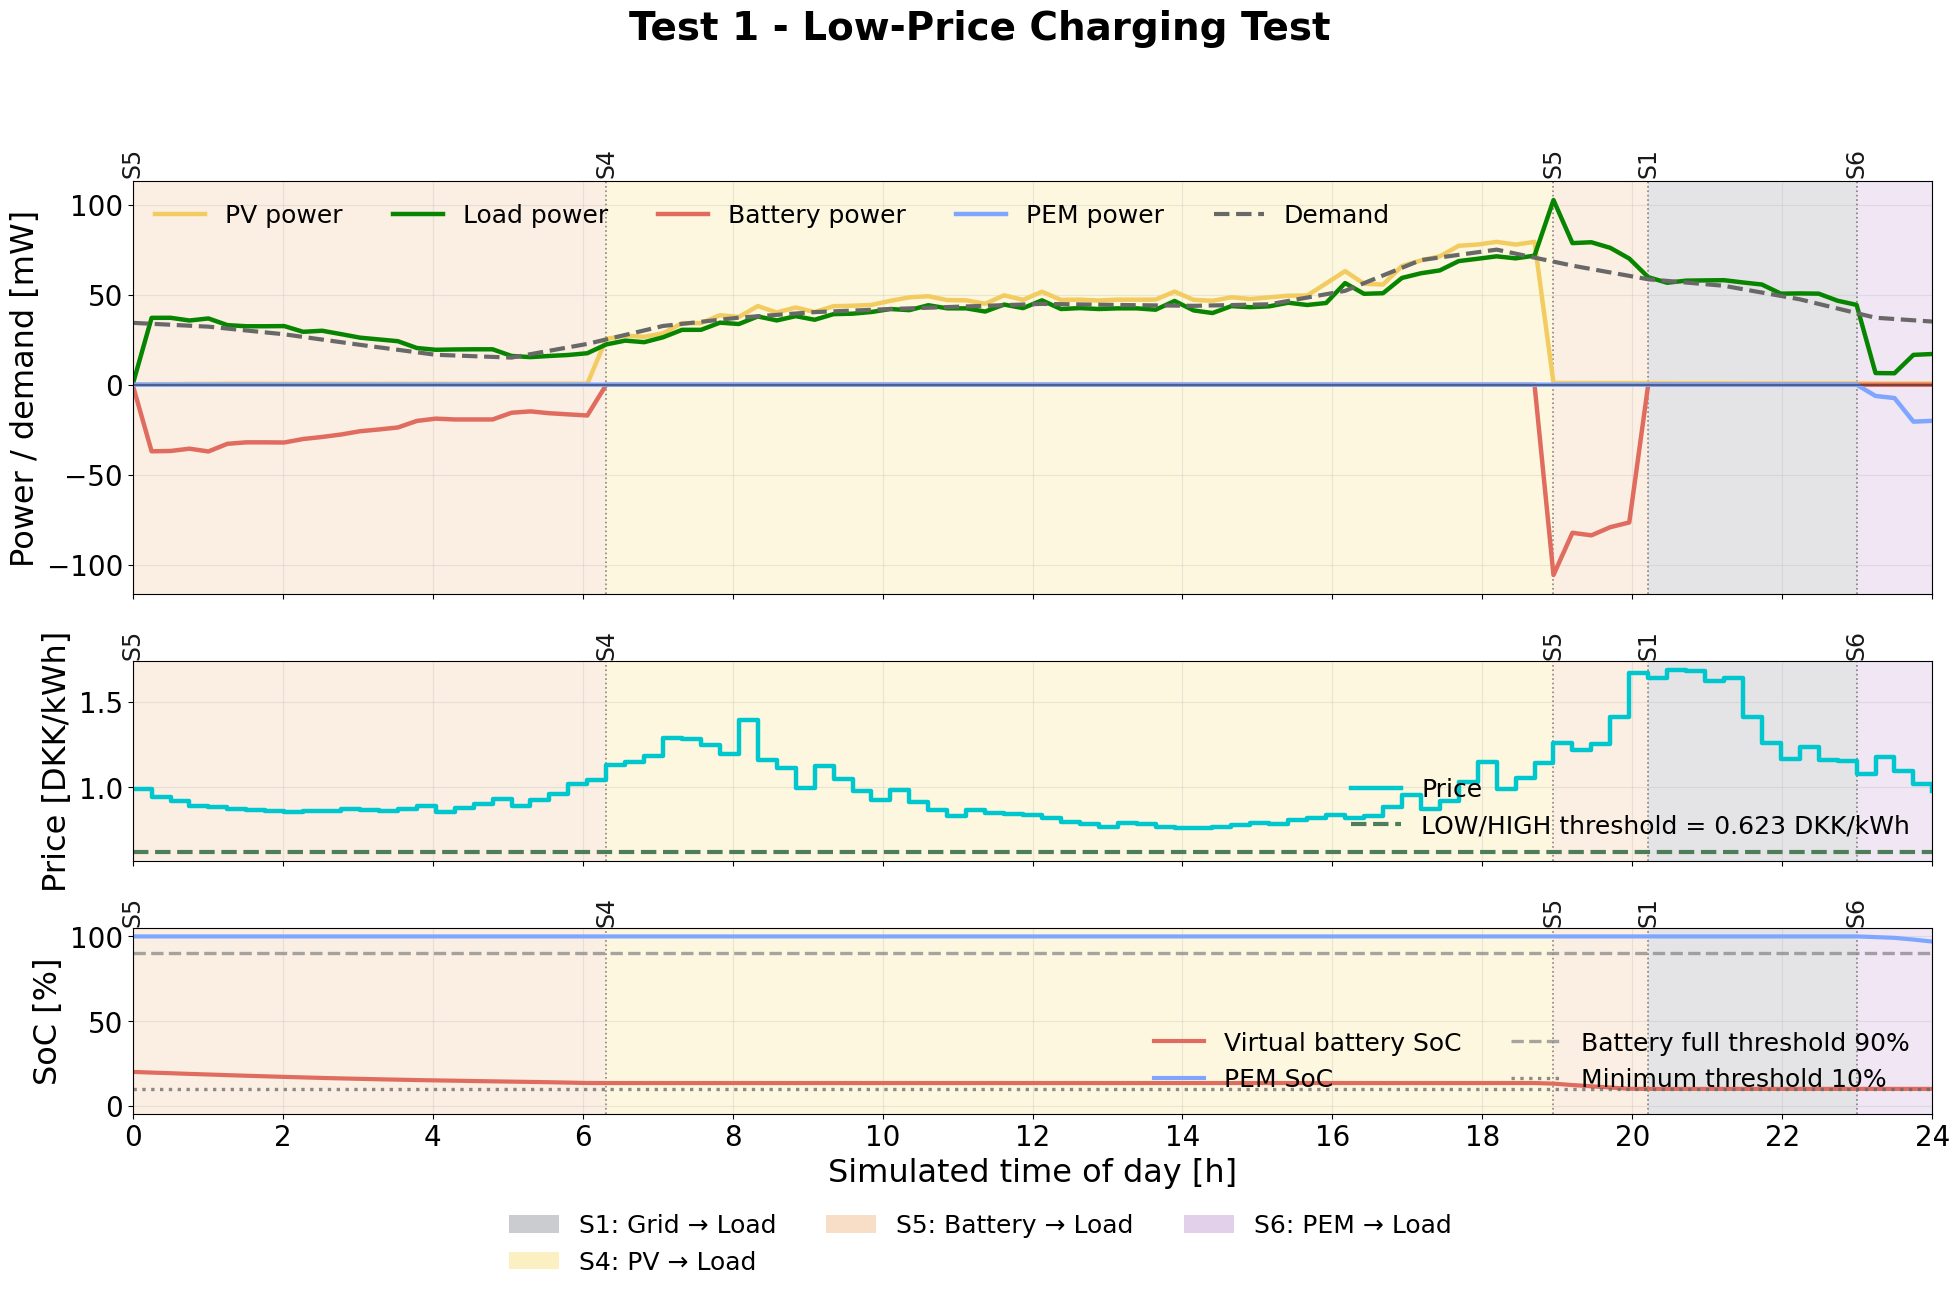

,Simulated time,Timeslot,Scenario,EMS reason
0,00:00,00:00-00:15,S5,"HIGH price, PV unavailable and battery has ene..."
25,06:15,06:15-06:30,S4,HIGH price and PV available -> PV supplies load.
75,18:45,18:45-19:00,S5,"HIGH price, PV unavailable and battery has ene..."
80,20:00,20:00-20:15,S1,"HIGH price, but load demand is too high for PE..."
91,22:45,22:45-23:00,S6,"HIGH price, PV unavailable, battery low, PEM h..."


Saved transition table: analysis_results\TEST2_ems_demo_20260512_133302_scenario_transitions.csv


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# File path
# ============================================================

# The IPYNB file is assumed to be in the same folder as the CSV file.
csv_path = Path(r"TEST2_ems_demo_20260512_133302")

# If the filepath was given without .csv, try adding it.
if not csv_path.exists() and csv_path.suffix == "":
    csv_path = csv_path.with_suffix(".csv")

print("Using file:", csv_path)


# ============================================================
# User settings
# ============================================================

scenario_column = "target_scenario"   # use "actual_scenario" to plot applied system scenario instead
show_soc = True
save_plot = True

plot_title = "Test 1 - Low-Price Charging Test"

price_threshold = 0.623   # DKK/kWh, LOW/HIGH threshold

out_dir = Path("analysis_results")
out_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# Report-friendly text sizes
# ============================================================

TITLE_SIZE = 28
AXIS_LABEL_SIZE = 23
TICK_LABEL_SIZE = 20
LEGEND_SIZE = 18
ANNOTATION_SIZE = 17

plt.rcParams.update({
    "font.size": TICK_LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": AXIS_LABEL_SIZE,
    "xtick.labelsize": TICK_LABEL_SIZE,
    "ytick.labelsize": TICK_LABEL_SIZE,
    "legend.fontsize": LEGEND_SIZE,
})


# ============================================================
# Colors
# ============================================================

WEBUI_COLORS = {
    "price": "#00C7CE",
    "price_threshold": "#4E7D5A",
    "demand": "#686868",
    "pv_power": "#F2CC60",
    "load_power": "#078500",
    "battery_power": "#E06C5F",
    "pem_power": "#7EA6FF",
}

SCENARIO_COLORS = {
    "S1": "#2f3542",
    "S2": "#2e8b57",
    "S3": "#1f77b4",
    "S4": "#f1c40f",
    "S5": "#e67e22",
    "S6": "#8e44ad",
}

SCENARIO_LABELS = {
    "S1": "S1: Grid → Load",
    "S2": "S2: Grid → Load, PV → Battery",
    "S3": "S3: Grid → Load, PV → PEM",
    "S4": "S4: PV → Load",
    "S5": "S5: Battery → Load",
    "S6": "S6: PEM → Load",
}


# ============================================================ 
# Helper functions
# ============================================================

def parse_time_axis_0_to_24(df):
    """
    Creates a simulated time-of-day x-axis from 0 to 24 hours.
    Uses time_label if available, otherwise slot, otherwise sample index.
    """

    if "time_label" in df.columns:
        parsed = pd.to_timedelta(df["time_label"].astype(str), errors="coerce")

        if parsed.notna().sum() > 0.5 * len(df):
            x = parsed.dt.total_seconds() / 3600.0
            return x, "Simulated time of day [h]"

    if "slot" in df.columns:
        slot = pd.to_numeric(df["slot"], errors="coerce")

        if slot.notna().sum() > 0.5 * len(df):
            slot_min = slot.min()
            slot_max = slot.max()

            if slot_max > slot_min:
                x = 24.0 * (slot - slot_min) / (slot_max - slot_min)
            else:
                x = slot * 0.0

            return x, "Simulated time of day [h]"

    sample_index = pd.Series(np.arange(len(df)), index=df.index)

    if len(df) > 1:
        x = 24.0 * sample_index / (len(df) - 1)
    else:
        x = sample_index * 0.0

    return x, "Simulated time of day [h]"


def normalize_scenario(value):
    """
    Converts scenario values such as S1, S1 Grid -> Load, or 1 into S1.
    """

    if pd.isna(value):
        return "Unknown"

    text = str(value).strip().upper()

    for scenario in ["S1", "S2", "S3", "S4", "S5", "S6"]:
        if text.startswith(scenario):
            return scenario

    if text in ["1", "2", "3", "4", "5", "6"]:
        return f"S{text}"

    return text


def find_transition_mask(scenario):
    """
    Returns True where the scenario changes.
    The first row is also treated as a transition/start point.
    """

    scenario_reset = scenario.reset_index(drop=True)
    return scenario_reset.ne(scenario_reset.shift())


def get_scenario_segments(x, scenario):
    """
    Converts the scenario series into continuous background regions.
    """

    x_values = x.to_numpy(dtype=float)
    scen_values = scenario.to_numpy()

    if len(x_values) == 0:
        return []

    dx_values = np.diff(x_values)
    dx_values = dx_values[np.isfinite(dx_values)]
    dx = np.nanmedian(dx_values) if len(dx_values) > 0 else 1.0

    segments = []
    start_idx = 0
    current_scenario = scen_values[0]

    for i in range(1, len(scen_values)):
        if scen_values[i] != current_scenario:
            segments.append((x_values[start_idx], x_values[i], current_scenario))
            start_idx = i
            current_scenario = scen_values[i]

    segments.append((x_values[start_idx], min(x_values[-1] + dx, 24), current_scenario))

    return segments


def add_scenario_background(ax, x, scenario):
    """
    Adds colored background regions according to active scenario.
    """

    for x_start, x_end, scen in get_scenario_segments(x, scenario):
        ax.axvspan(
            x_start,
            x_end,
            color=SCENARIO_COLORS.get(scen, "#dcdde1"),
            alpha=0.13,
            linewidth=0,
            zorder=0,
        )


def add_transition_markers(ax, x, scenario):
    """
    Adds vertical lines and scenario labels where scenario changes.
    """

    scenario_reset = scenario.reset_index(drop=True)
    x_reset = x.reset_index(drop=True)
    change_mask = find_transition_mask(scenario)

    for xpos, scen in zip(x_reset[change_mask], scenario_reset[change_mask]):
        ax.axvline(
            xpos,
            color="black",
            linestyle=":",
            linewidth=1.2,
            alpha=0.45,
            zorder=1,
        )

        ax.text(
            xpos,
            1.01,
            scen,
            transform=ax.get_xaxis_transform(),
            rotation=90,
            va="bottom",
            ha="center",
            fontsize=ANNOTATION_SIZE,
            alpha=0.9,
        )


# ============================================================
# Load data
# ============================================================

df = pd.read_csv(csv_path)

print("Rows:", len(df))
print("Columns:", len(df.columns))

if scenario_column not in df.columns:
    raise ValueError(
        f"Could not find scenario column: {scenario_column}. "
        f"Available columns are:\n{list(df.columns)}"
    )

x, x_label = parse_time_axis_0_to_24(df)
scenario = df[scenario_column].apply(normalize_scenario)

numeric_columns = [
    "pv_power_mW",
    "battery_power_mW",
    "pem_power_mW",
    "load_power_mW",
    "demand_mW",
    "price_dkk_kwh",
    "virtual_battery_soc_percent",
    "pem_soc_percent",
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ============================================================
# Create figure
# ============================================================

if show_soc:
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(20, 13),
        sharex=True,
        gridspec_kw={"height_ratios": [3.1, 1.5, 1.4]},
    )
    ax_power, ax_price, ax_soc = axes
else:
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(20, 10),
        sharex=True,
        gridspec_kw={"height_ratios": [3.1, 1.5]},
    )
    ax_power, ax_price = axes
    ax_soc = None

fig.suptitle(
    plot_title,
    fontsize=TITLE_SIZE,
    fontweight="bold",
)

for ax in axes:
    add_scenario_background(ax, x, scenario)


# ============================================================
# Plot 1: Power flows and demand
# ============================================================

power_columns = {
    "pv_power_mW": ("PV power", WEBUI_COLORS["pv_power"]),
    "load_power_mW": ("Load power", WEBUI_COLORS["load_power"]),
    "battery_power_mW": ("Battery power", WEBUI_COLORS["battery_power"]),
    "pem_power_mW": ("PEM power", WEBUI_COLORS["pem_power"]),
}

for col, (label, color) in power_columns.items():
    if col in df.columns:
        ax_power.plot(
            x,
            df[col],
            linewidth=3.2,
            label=label,
            color=color,
        )

if "demand_mW" in df.columns:
    ax_power.plot(
        x,
        df["demand_mW"],
        linewidth=3.0,
        linestyle="--",
        label="Demand",
        color=WEBUI_COLORS["demand"],
    )

ax_power.axhline(
    0,
    color="black",
    linewidth=1.2,
    alpha=0.5,
)

ax_power.set_ylabel("Power / demand [mW]")
ax_power.grid(True, alpha=0.25)

ax_power.legend(
    loc="upper left",
    ncol=5,
    frameon=False,
)

add_transition_markers(ax_power, x, scenario)


# ============================================================
# Plot 2: Electricity price with LOW/HIGH threshold
# ============================================================

if "price_dkk_kwh" in df.columns:
    ax_price.step(
        x,
        df["price_dkk_kwh"],
        where="post",
        linewidth=3.2,
        label="Price",
        color=WEBUI_COLORS["price"],
    )

    ax_price.axhline(
        price_threshold,
        linewidth=3.0,
        linestyle="--",
        label=f"LOW/HIGH threshold = {price_threshold:.3f} DKK/kWh",
        color=WEBUI_COLORS["price_threshold"],
    )

    ax_price.set_ylabel("Price [DKK/kWh]")

    ax_price.legend(
        loc="upper left",
        frameon=False,
    )

else:
    ax_price.text(
        0.5,
        0.5,
        "No price_dkk_kwh column found",
        transform=ax_price.transAxes,
        ha="center",
        va="center",
        fontsize=AXIS_LABEL_SIZE,
    )
    ax_price.set_ylabel("Price")

ax_price.grid(True, alpha=0.25)
add_transition_markers(ax_price, x, scenario)


# ============================================================
# Plot 3: SoC states
# ============================================================

if show_soc and ax_soc is not None:
    soc_columns = {
        "virtual_battery_soc_percent": (
            "Virtual battery SoC",
            WEBUI_COLORS["battery_power"],
        ),
        "pem_soc_percent": (
            "PEM SoC",
            WEBUI_COLORS["pem_power"],
        ),
    }

    for col, (label, color) in soc_columns.items():
        if col in df.columns:
            ax_soc.plot(
                x,
                df[col],
                linewidth=3.0,
                label=label,
                color=color,
            )

    ax_soc.axhline(
        90,
        linestyle="--",
        linewidth=2.4,
        alpha=0.75,
        label="Battery full threshold 90%",
        color="#888888",
    )

    ax_soc.axhline(
        10,
        linestyle=":",
        linewidth=2.4,
        alpha=0.75,
        label="Minimum threshold 10%",
        color="#666666",
    )

    ax_soc.set_ylabel("SoC [%]")
    ax_soc.set_ylim(-5, 105)
    ax_soc.grid(True, alpha=0.25)

    ax_soc.legend(
        loc="lower right",
        ncol=2,
        frameon=False,
    )

    add_transition_markers(ax_soc, x, scenario)


# ============================================================
# Shared x-axis formatting
# ============================================================

axes[-1].set_xlabel(x_label)

for ax in axes:
    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 2))
    ax.tick_params(axis="both", which="major", labelsize=TICK_LABEL_SIZE)


# ============================================================
# Scenario legend and formatting
# ============================================================

used_scenarios = sorted(set(scenario.dropna()))

scenario_handles = [
    Patch(
        facecolor=SCENARIO_COLORS[scen],
        alpha=0.25,
        label=SCENARIO_LABELS.get(scen, scen),
    )
    for scen in used_scenarios
    if scen in SCENARIO_COLORS
]

if scenario_handles:
    fig.legend(
        handles=scenario_handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, -0.01),
        fontsize=LEGEND_SIZE,
    )

fig.tight_layout(rect=[0, 0.05, 1, 0.95])


# ============================================================
# Save and show plot
# ============================================================

if save_plot:
    png_path = out_dir / f"{csv_path.stem}_timeline.png"
    pdf_path = out_dir / f"{csv_path.stem}_timeline.pdf"

    fig.savefig(
        png_path,
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print("Saved PNG:", png_path)
    print("Saved PDF:", pdf_path)

plt.show()


# ============================================================
# Scenario transition table
# ============================================================

scenario_reset = scenario.reset_index(drop=True)
change_mask = find_transition_mask(scenario)

transition_rows = df.loc[change_mask.values].copy()
transition_rows["scenario"] = scenario_reset[change_mask].values

table_columns = []

if "time_label" in transition_rows.columns:
    table_columns.append("time_label")

if "interval_label" in transition_rows.columns:
    table_columns.append("interval_label")

table_columns.append("scenario")

if "scheduler_reason" in transition_rows.columns:
    table_columns.append("scheduler_reason")

transitions = transition_rows[table_columns].copy()

transitions = transitions.rename(columns={
    "time_label": "Simulated time",
    "interval_label": "Timeslot",
    "scenario": "Scenario",
    "scheduler_reason": "EMS reason",
})

display(transitions)

transition_csv = out_dir / f"{csv_path.stem}_scenario_transitions.csv"
transitions.to_csv(transition_csv, index=False)

print("Saved transition table:", transition_csv)

## Test 3

## Test 4